# From Radar to Roads: 2020 Southwest Sweden Floods & Hospital Accessibility

**Workshop segment: From flood mapping to critical infrastructure accessibility**

No coding experience needed — every cell is pre-written. Your job is to **run each cell in order** and read the short prompts that ask you to interpret the output.

## The story

In February 2020, storms Ciara and Dennis brought heavy, sustained rainfall to southwestern Sweden, causing serious flooding along several river systems.

- Sweden's Civil Contingencies Agency (**MSB**) activated the **Copernicus Emergency Management Service** (Rapid Mapping, activation **EMSR427**) on 18 February 2020.
- The activation covered **12 areas of interest across 41,222.61 km²** of southern Sweden, including Sjuhärad, Skaraborg, Göteborg, Jönköping, Kronoberg and others.
- This notebook focuses on the **Sjuhärad** area, specifically the **Viskan river** around **Borås** — one of the two rivers EFAS flagged with the highest flood risk in this event.

## What you'll do

1. Pull a **before/during** pair of Sentinel-1 radar images over the flood area.
2. Detect flooded ground from the radar signal.
3. Turn the flood mask into a shape (polygon) we can overlay on a map.
4. Pull the road network and critical facilities (hospitals, schools, police/fire stations) locations from OpenStreetMap.
5. Work out which roads the flood likely cut off, and how that affects access to **each** of those critical facility categories.
6. Estimate how many people the flood zone covers, and check the flood extent itself against **land cover** — both to see what kind of land is most affected, and as a quality check on the radar-based flood detection.

## Data sources

| Data | Source | Account needed? |
|---|---|---|
| Sentinel-1 GRD SAR (VH) | Copernicus Data Space Ecosystem | **Yes** — see Section 2 |
| Roads + hospitals | OpenStreetMap (`osmnx`) | No |
| Population grid | *SCB (Statistics Sweden), 1 km grid -> GitHub repository*  | No |
| Land cover raster | *NMD2018 (Naturvårdsverket) -> GitHub repository*  | No |

In [ ]:
# Run this cell once. It installs everything the notebook needs.
%pip install -q sentinelhub rioxarray rasterio scipy \
    geopandas shapely osmnx networkx matplotlib contextily
print("Packages installed:)")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.4/240.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
Packages installed:)


In [ ]:
# Imports
import os
import warnings
warnings.filterwarnings("ignore")

import getpass
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import FuncFormatter


import rioxarray
import xarray as xr
from rasterio.features import shapes as rio_shapes
from shapely.geometry import shape as shapely_shape, box
from shapely.ops import unary_union

from sentinelhub import (
    SHConfig, SentinelHubRequest, DataCollection, MimeType,
    CRS, BBox, bbox_to_dimensions)

import requests
import osmnx as ox
import networkx as nx
import folium
import contextily as ctx

import math
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from scipy.ndimage import median_filter

from google.colab import files

import urllib.request
print("Imports OK:)")


Imports OK:)


## 1. Study area

We focus on the **Viskan river valley from Borås down to Skene**, in the Sjuhärad area of Västra Götaland — one of the 12 areas covered by the EMSR427 activation. The AOI is widened to capture **both** Södra Älvsborgs Sjukhus (SÄS) hospital sites, Borås and Skene, so the accessibility analysis later isn't limited to one critical building of each type.

**Activity (optional)**: Feel free to change `AOI_BBOX` below and re-run everything if you want a different stretch of the river, or one of the other EMSR427 areas (Skaraborg, Göteborg, etc.).

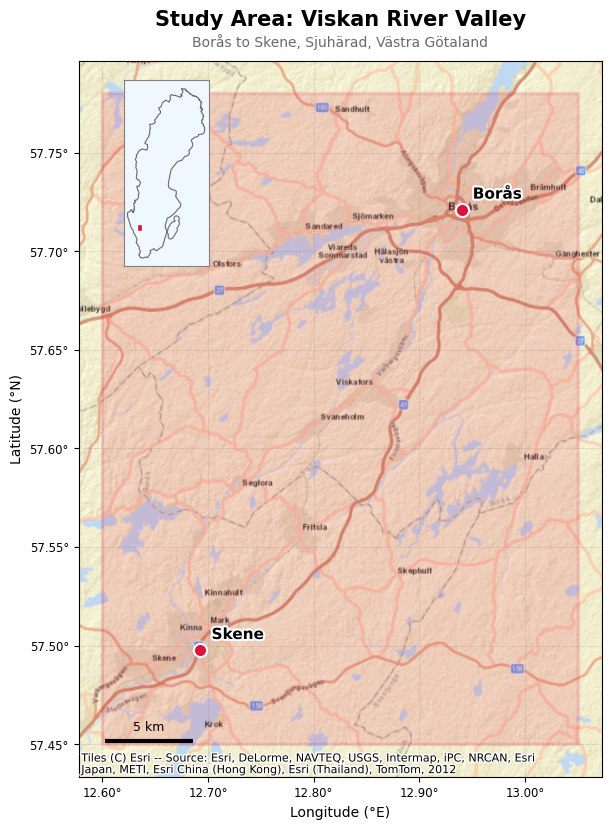

In [ ]:
# Bounding box: (min_lon, min_lat, max_lon, max_lat)
# Viskan river valley, Borås to Skene, Sjuhärad, Västra Götaland
AOI_BBOX = (12.60, 57.45, 13.05, 57.78)
AOI_GEOM = box(*AOI_BBOX)
AOI_SH = BBox(bbox=AOI_BBOX, crs=CRS.WGS84)
METRIC_CRS = "EPSG:32633"  # UTM 33N, used for every area/length/distance calculation below

# A calm baseline window, and a window inside the Feb 2020 flood event (EMSR427
# official mapping ran 19 Feb - 4 Mar 2020).
BASELINE_DATE_RANGE = ("2020-01-15", "2020-01-31")
FLOOD_DATE_RANGE    = ("2020-02-18", "2020-03-04")

aoi_wgs = gpd.GeoSeries([AOI_GEOM], crs="EPSG:4326")

#Plot AOI
fig, ax = plt.subplots(figsize=(9, 8.5))
fig.patch.set_facecolor("white")

aoi_wgs.plot(ax=ax, facecolor="crimson", alpha=0.15, edgecolor="crimson", linewidth=2.5, zorder=2)
basemap_loaded = False
for provider in [ctx.providers.Esri.WorldStreetMap, ctx.providers.Esri.WorldGrayCanvas]:
    try:
        ctx.add_basemap(ax, crs="EPSG:4326", source=provider, zorder=1)
        basemap_loaded = True
        break
    except Exception:
        continue
#if not basemap_loaded:
    #ax.set_facecolor("#eef3f7")
    #print("Basemap tiles unavailable right now -- showing the AOI on a plain background instead.")

# Town labels
towns = {"Borås": (12.9401, 57.7210), "Skene": (12.6928, 57.4977)}
for name, (lon, lat) in towns.items():
    ax.scatter(lon, lat, s=90, color="crimson", edgecolor="white", linewidth=1.5, zorder=4)
    ax.annotate(name, (lon, lat), xytext=(8, 8), textcoords="offset points",
                fontsize=11, fontweight="bold", color="black",
                path_effects=[__import__("matplotlib.patheffects", fromlist=["withStroke"]).withStroke(linewidth=3, foreground="white")])

# Lat/lon frame instead of a bare axis: gridlines + degree-formatted ticks.
ax.set_xlabel("Longitude (°E)", fontsize=10)
ax.set_ylabel("Latitude (°N)", fontsize=10)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}°"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}°"))
ax.tick_params(labelsize=8.5)
ax.grid(True, linestyle=":", alpha=0.5, color="gray", linewidth=0.6)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

fig.suptitle("Study Area: Viskan River Valley", fontsize=15, fontweight="bold", y=0.97)
ax.set_title("Borås to Skene, Sjuhärad, Västra Götaland", fontsize=10, color="dimgray", pad=10)

# Scale bar (5 km) -- convert km to degrees longitude at the AOI's latitude.
center_lat = (AOI_BBOX[1] + AOI_BBOX[3]) / 2
km_per_deg_lon = 111.32 * math.cos(math.radians(center_lat))
bar_length_deg = 5 / km_per_deg_lon
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
bar_x0 = x0 + (x1 - x0) * 0.05
bar_y0 = y0 + (y1 - y0) * 0.05
ax.plot([bar_x0, bar_x0 + bar_length_deg], [bar_y0, bar_y0], color="black", linewidth=3, solid_capstyle="butt")
ax.text(bar_x0 + bar_length_deg / 2, bar_y0 + (y1 - y0) * 0.015, "5 km", ha="center", fontsize=9)

# Locator inset: where is this within Sweden?
try:
    sweden_gdf = ox.geocode_to_gdf("Sweden")
    inset = inset_axes(ax, width="26%", height="26%", loc="upper left", borderpad=1.4)
    sweden_gdf.boundary.plot(ax=inset, color="dimgray", linewidth=0.8)
    inset.add_patch(mpatches.Rectangle((AOI_BBOX[0], AOI_BBOX[1]), AOI_BBOX[2] - AOI_BBOX[0], AOI_BBOX[3] - AOI_BBOX[1],
                                        facecolor="crimson", edgecolor="crimson", linewidth=1.2))
    inset.set_xticks([]); inset.set_yticks([])
    inset.set_facecolor("aliceblue")
    for spine in inset.spines.values():
        spine.set_edgecolor("gray")
except Exception as e:
    print(f"Locator inset skipped ({type(e).__name__}) -- not essential, main map above is unaffected.")

plt.tight_layout()
plt.show()

## 2. Sentinel-1 acquisition

### Why radar (SAR) and not an ordinary satellite photo?

Optical satellites (like Sentinel-2) take photos — useless under cloud, and southwestern Sweden in late February is often cloudy. **Sentinel-1** is a *radar* satellite: it sends down its own microwave pulses and measures what bounces back, day or night, through cloud. Smooth surfaces (open water, flooded fields) reflect the signal *away* from the satellite, so they look **dark** in the image. That's the basis of our flood detection.

We use the **VH polarization** band, which is generally the more reliable single band for water detection.

### How we fetch the data

We use the **Sentinel Hub Process API** (part of the Copernicus Data Space Ecosystem). Instead of downloading a raw scene and fixing it up locally, we ask the server for exactly the processed product we want:

- bounding box = our AOI directly, in WGS84 (lat/lon)
- already orthorectified, terrain-corrected gamma0 backscatter in dB
- overlapping tiles for the date range are mosaicked server-side automatically

This needs a free **Sentinel Hub OAuth client** (client ID + secret) from your Copernicus Data Space Ecosystem account: Profile icon → **Sentinel Hub** → User Settings → *create new OAuth client*.

In [ ]:
# Authenticate against the Copernicus Data Space Ecosystem's Sentinel Hub.
# You'll be prompted below -- nothing is printed or saved into the notebook file.
config = SHConfig()
config.sh_client_id = getpass.getpass("Sentinel Hub client ID: ")
config.sh_client_secret = getpass.getpass("Sentinel Hub client secret: ")
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"

print("Config set.")

Sentinel Hub client ID: ··········
Sentinel Hub client secret: ··········
Config set.


In [ ]:
# DataCollection.SENTINEL1_IW / SENTINEL2_L2A point at services.sentinel-hub.com by
# default -- setting config.sh_base_url alone doesn't redirect them, so we bind
# CDSE-flavoured copies explicitly and use *those* everywhere below.
S1_IW_CDSE = DataCollection.SENTINEL1_IW.define_from("s1iw_cdse", service_url=config.sh_base_url)
S2_L2A_CDSE = DataCollection.SENTINEL2_L2A.define_from("s2l2a_cdse", service_url=config.sh_base_url)

print("CDSE-bound collections ready.")

CDSE-bound collections ready.


In [ ]:
DST_CRS_SH = CRS.UTM_33N
RESOLUTION_M = 15   # 10 m native, but the AOI is large enough that 10 m would exceed the
                     # Process API's ~2500px/side synchronous request limit; 15 m stays under it.

aoi_size = bbox_to_dimensions(AOI_SH, resolution=RESOLUTION_M)
print(f"Output raster size for this AOI at {RESOLUTION_M} m: {aoi_size} px")

# VH backscatter, terrain-corrected (gamma0), in dB -- matches the Copernicus
# Browser's "VH - decibel gamma0" layer.
EVALSCRIPT_S1_VH_DB = """
//VERSION=3
function setup() {
  return { input: ["VH"], output: { bands: 1, sampleType: "FLOAT32" } };
}
function evaluatePixel(sample) {
  return [10 * Math.log10(sample.VH)];
}
"""

os.makedirs("sh_cache", exist_ok=True)

def fetch_s1_vh_db_geotiff(date_range, tag, bbox=AOI_SH, size=aoi_size, config=config):
    request = SentinelHubRequest(
        data_folder="sh_cache",
        evalscript=EVALSCRIPT_S1_VH_DB,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=S1_IW_CDSE,
                time_interval=date_range,
                mosaicking_order="mostRecent",
                other_args={"processing": {"backCoeff": "GAMMA0_TERRAIN", "orthorectify": True}},
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox, size=size, config=config,
    )
    request.get_data(save_data=True)
    full_path = os.path.join("sh_cache", request.get_filename_list()[0])
    da = rioxarray.open_rasterio(full_path, masked=True).squeeze()
    print(f"{tag}: loaded {full_path}, shape {da.shape}, CRS {da.rio.crs}")
    return da

baseline_vh = fetch_s1_vh_db_geotiff(BASELINE_DATE_RANGE, "baseline")
flood_vh    = fetch_s1_vh_db_geotiff(FLOOD_DATE_RANGE, "flood")

Output raster size for this AOI at 15 m: (1870, 2391) px
baseline: loaded sh_cache/96bd6bb275d55e695ed000932a8469b6/response.tiff, shape (2391, 1870), CRS EPSG:4326
flood: loaded sh_cache/1b9c9b834d9d1111ebd514125197398d/response.tiff, shape (2391, 1870), CRS EPSG:4326


### How to read a radar image

The plots below are **not photographs** — there's no color, no sunlight, nothing "looks like" what a camera would show. Each pixel is just a number: how much of the radar's own signal bounced back to the satellite, shown in **grayscale** and measured in **decibels (dB)**, a logarithmic scale (like sound loudness).

- **Dark pixels** = weak return. The signal mostly bounced *away* from the satellite instead of back. This happens over smooth surfaces — calm water, wet flat ground, some roads.
- **Bright pixels** = strong return. Rougher surfaces (forest canopy, plowed fields) and vertical structures (buildings, especially their corners) scatter the signal back toward the satellite efficiently.
- **Grainy, salt-and-pepper texture** everywhere is normal — it's called *speckle*, an inherent property of how radar works, not a data quality problem. Section 3 removes it before doing any detection.

**Keep the "dark = smooth = possibly water" rule in mind for the next plot**.

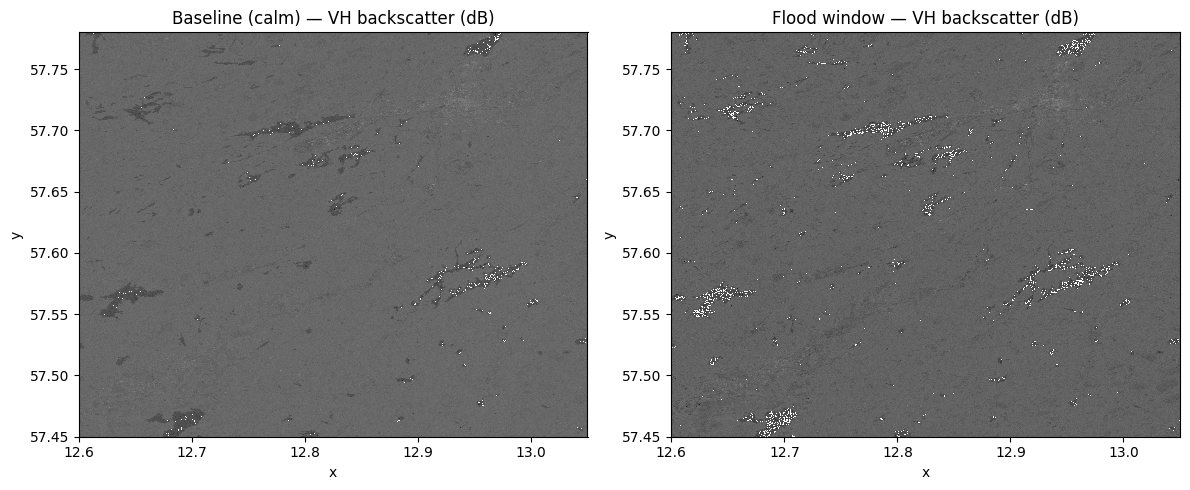

In [ ]:
# Quick visual sanity check: do these look like real radar images
 #(not blank / all-nodata)?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
baseline_vh.plot(ax=axes[0], cmap="gray", add_colorbar=False)
axes[0].set_title("Baseline (calm) — VH backscatter (dB)")
flood_vh.plot(ax=axes[1], cmap="gray", add_colorbar=False)
axes[1].set_title("Flood window — VH backscatter (dB)")
plt.tight_layout()
plt.show()

**Activity (optional)**: do you see darker patches in the flood-window image that aren't in the baseline image? Those are candidate flooded areas — smooth water reflects the radar signal away from the sensor. We'll turn that visual impression into an actual flood mask next.


### Making the difference visible

Two grayscale radar images side by side are hard to compare by eye — small changes get lost in the speckle. So instead of looking at the two images separately, we subtract them: **baseline minus flood-window**, pixel by pixel.

- **Red** = the signal got *weaker* during the flood window (a candidate sign of new flooding — a surface that used to scatter radar well became smoother).
- **Blue** = the signal got *stronger* — less common, but real. Storms bring wind, and wind roughens the surface of already-existing water, which can *increase* backscatter instead of decreasing it. This is a genuine limitation of a simple threshold method, not a mistake in the data.
- **White/pale** = little to no change — most of the AOI, since only a small fraction actually flooded.

**Activity (optional)**: Look for **red areas that trace a linear or branching shape** — that's consistent with a river valley flooding. Scattered, isolated red pixels with no spatial pattern are more likely to be speckle noise, not real flooding.

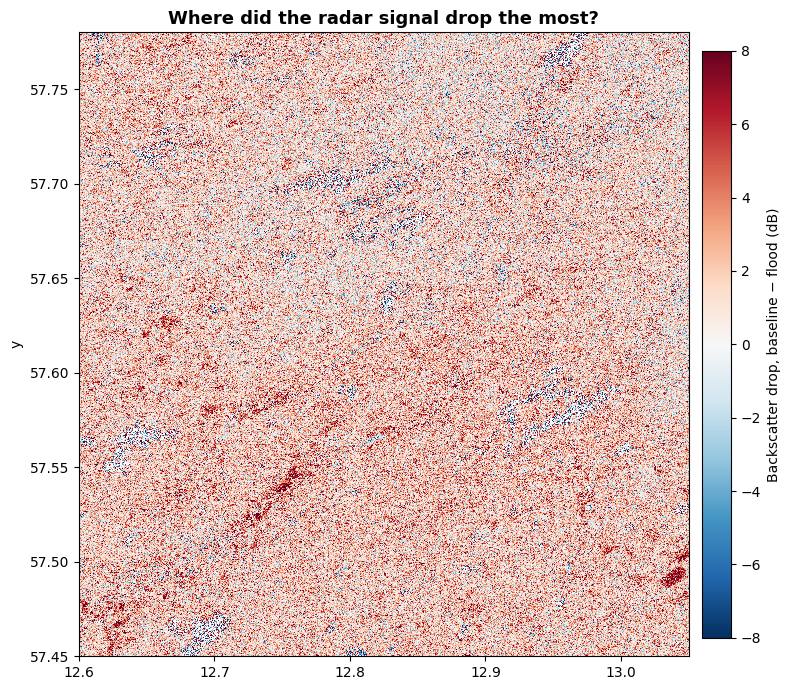

In [ ]:
# Difference map: baseline dB minus flood-window dB, at the same pixel.
# A large POSITIVE value means the signal dropped a lot during the flood window --
# exactly what we expect where smooth floodwater replaced rough, dry ground.
diff_db = baseline_vh - flood_vh.rio.reproject_match(baseline_vh)

fig, ax = plt.subplots(figsize=(8, 7))
im = diff_db.plot(ax=ax, cmap="RdBu_r", vmin=-8, vmax=8, add_colorbar=False)
cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label("Backscatter drop, baseline − flood (dB)", fontsize=10)

ax.set_title("Where did the radar signal drop the most?", fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude" if "x" not in diff_db.dims else "")
plt.tight_layout()
plt.show()


### Bonus: Sentinel-2

**Sentinel-2** is an ordinary optical satellite — it takes true-color photos, the way a camera would, instead of sending its own signal like radar. The "trick" is the same one we just used for Sentinel-1: pull a **before** and **during** image of the same place, and compare them.

What to look for if the images load: flooded fields and roads often turn a murky brown/gray compared to their normal color, and open water spreads beyond its usual boundary (rivers, lakes visibly wider than in the baseline image).

**The catch:** clouds. Unlike radar, an optical satellite can't see through them — and storms that cause flooding usually come with heavy cloud cover. If part of the flood-window image comes back black, that's not a bug: it means no cloud-free Sentinel-2 pass was available for that area during the flood. **That failure is itself the argument for why this notebook uses SAR as the primary method**, not a fallback.

Purely a visual, independent sanity check — not used in the flood-detection math. **Activity (optional):** run this cell  with various **max_cloud values (0.8, 0.6, 0.3 etc.)** for the extra check

S2 baseline: loaded Sentinel-2 true color, shape (3, 2391, 1870)
S2 flood-window: loaded Sentinel-2 true color, shape (3, 2391, 1870)


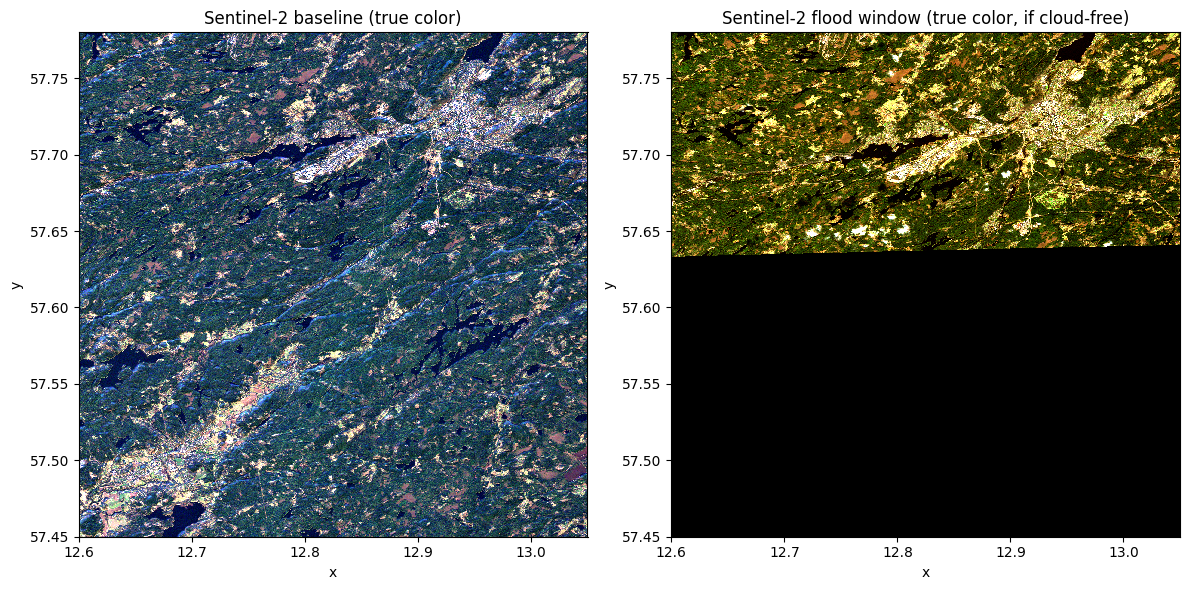

In [ ]:
EVALSCRIPT_S2_TRUE_COLOR = """
//VERSION=3
function setup() {
  return { input: ["B04", "B03", "B02"], output: { bands: 3, sampleType: "FLOAT32" } };
}
function evaluatePixel(sample) {
  return [sample.B04 * 2.5, sample.B03 * 2.5, sample.B02 * 2.5];
}
"""

def fetch_s2_true_color(date_range, tag, bbox=AOI_SH, size=aoi_size, config=config, max_cloud=0.3):
  #try also alter max_cloud to 0.6 or/and 0.8
    request = SentinelHubRequest(
        data_folder="sh_cache",
        evalscript=EVALSCRIPT_S2_TRUE_COLOR,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=S2_L2A_CDSE, time_interval=date_range,
                mosaicking_order="leastCC", maxcc=max_cloud,
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox, size=size, config=config,
    )
    try:
        request.get_data(save_data=True)
        tiff_path = os.path.join("sh_cache", request.get_filename_list()[0])
        da = rioxarray.open_rasterio(tiff_path)
        print(f"{tag}: loaded Sentinel-2 true color, shape {da.shape}")
        return da
    except Exception as e:
        print(f"{tag}: Sentinel-2 fetch failed ({type(e).__name__}) -- likely no cloud-free scene. Skip this bonus.")
        return None

s2_baseline_rgb = fetch_s2_true_color(BASELINE_DATE_RANGE, "S2 baseline")
s2_flood_rgb    = fetch_s2_true_color(FLOOD_DATE_RANGE, "S2 flood-window")

if s2_baseline_rgb is not None and s2_flood_rgb is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    s2_baseline_rgb.plot.imshow(ax=axes[0], robust=True)
    axes[0].set_title("Sentinel-2 baseline (true color)")
    s2_flood_rgb.plot.imshow(ax=axes[1], robust=True)
    axes[1].set_title("Sentinel-2 flood window (true color, if cloud-free)")
    plt.tight_layout()
    plt.show()

## 3. SAR flood detection

We flag a pixel as "flooded" if:
1. its flood-window value is below an absolute water threshold, **and**
2. it dropped substantially relative to the baseline (so we don't flag things that were already water — lakes, rivers — as "newly flooded").

### Speckle noise

Radar images have a grainy, salt-and-pepper texture called **speckle**, inherent to how radar works. Left unfiltered, thresholding pixel-by-pixel flags huge numbers of isolated noise pixels as "flooded". The fix is a **speckle filter** — here, a median filter — applied to the dB values before thresholding.

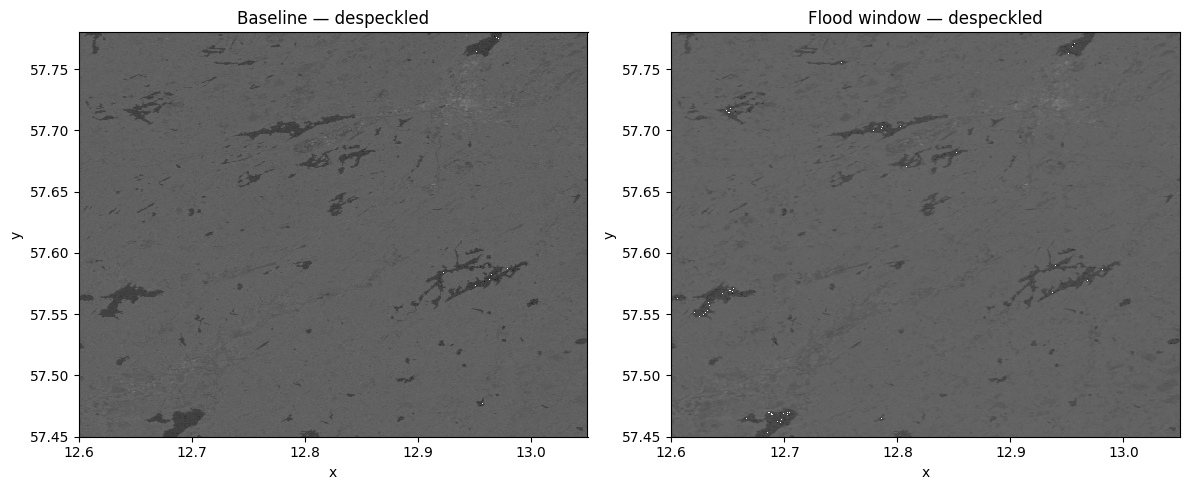

In [ ]:
def despeckle(da, size=5):
    """Median-filter speckle reduction. size=5/7 (50x50m window) is a reasonable default at 10m res."""
    return da.copy(data=median_filter(da.values, size=size))

baseline_db_smooth = despeckle(baseline_vh, size=5)
flood_db_smooth = despeckle(flood_vh, size=7)  # slightly stronger filter for the noisier stormy image

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
baseline_db_smooth.plot(ax=axes[0], cmap="gray", add_colorbar=False)
axes[0].set_title("Baseline — despeckled")
flood_db_smooth.plot(ax=axes[1], cmap="gray", add_colorbar=False)
axes[1].set_title("Flood window — despeckled")
plt.tight_layout()
plt.show()

### Sentinel-derived flood extent

The flood mask below is derived **purely from the Sentinel-1 workflow** — the despeckled backscatter you just looked at, thresholded using `DB_WATER_THRESHOLD` and `DB_DROP_THRESHOLD` from the previous cell. No DEM, no slope filtering, no manual editing of the result.

This is a deliberate choice for this notebook: it keeps the Earth Observation part transparent and inspectable — every flagged pixel traces back to a rule you can see and change — rather than hiding the logic behind a more complex, harder-to-explain method.


Flooded pixels: 254,754 / 4,471,170 (5.70% of the AOI)


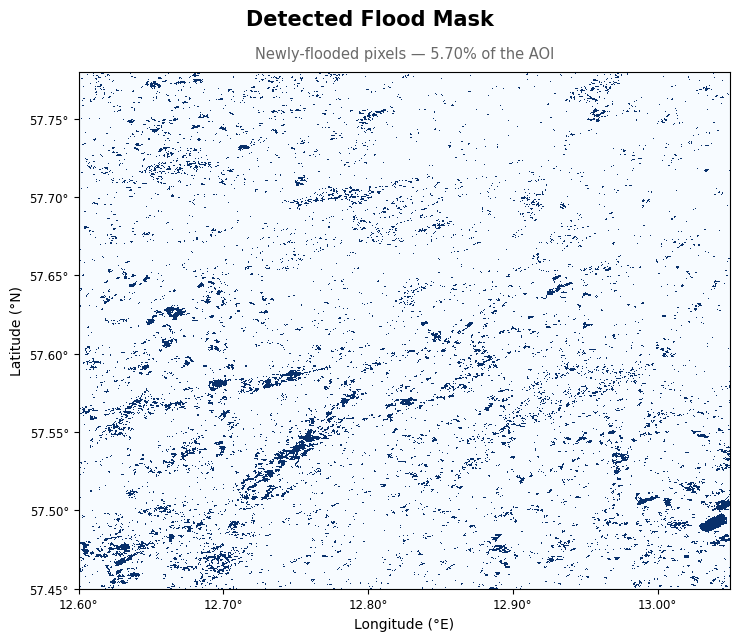

≈ 57.32 km² of newly-flooded ground


In [ ]:
# baseline_vh / flood_vh are already in dB (computed server-side), so we threshold the
# despeckled dB arrays directly -- no further conversion needed.
baseline_db_aligned = baseline_db_smooth
flood_db_aligned = flood_db_smooth.rio.reproject_match(baseline_db_smooth)  # align grids (requests can differ by a pixel or two)

DB_WATER_THRESHOLD = -17.0   # typical VH water threshold, in dB; tune if needed
DB_DROP_THRESHOLD  = 3.0     # must have dropped at least this many dB vs baseline

drop = baseline_db_aligned - flood_db_aligned
flood_mask = (flood_db_aligned < DB_WATER_THRESHOLD) & (drop > DB_DROP_THRESHOLD)

n_flooded_px = int(flood_mask.sum())
n_total_px = int(flood_mask.size)
pct_flooded = 100 * n_flooded_px / n_total_px
print(f"Flooded pixels: {n_flooded_px:,} / {n_total_px:,} ({pct_flooded:.2f}% of the AOI)")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
fig.patch.set_facecolor("white")

flood_mask.plot(ax=ax, cmap="Blues", add_colorbar=False, vmin=0, vmax=1)  # pin vmin/vmax so an empty result plots white, not mid-colormap

fig.suptitle("Detected Flood Mask", fontsize=15, fontweight="bold", y=0.98)
ax.set_title(f"Newly-flooded pixels — {pct_flooded:.2f}% of the AOI", fontsize=10.5, color="dimgray", pad=10)

ax.set_xlabel("Longitude (°E)", fontsize=10)
ax.set_ylabel("Latitude (°N)", fontsize=10)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}°"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}°"))
ax.tick_params(labelsize=8.5)

plt.tight_layout()
plt.show()

# flood_mask.rio.resolution() reports degrees, not meters, because the S1 raster's
# coordinates ended up in WGS84 (lat/lon) rather than the intended UTM CRS -- so we
# use the resolution we actually requested from Sentinel Hub instead.
px_area_m2 = RESOLUTION_M ** 2  # 15m x 15m pixels
print(f"≈ {n_flooded_px * px_area_m2 / 1e6:.2f} km² of newly-flooded ground")

## 4. Vectorize the flood mask

A raster mask is fine for plotting, but for the accessibility analysis we need actual **polygons** we can intersect with roads. This cell turns the pixel mask into a `GeoDataFrame` of flood polygons, drops tiny noise polygons, and simplifies the shapes slightly.

3821 flood polygon(s) after cleanup


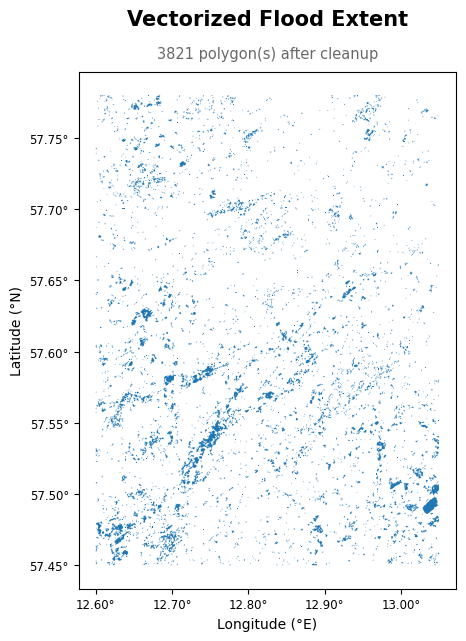

In [ ]:
mask_arr = flood_mask.values.astype("uint8")
transform = flood_mask.rio.transform()

polygons = [shapely_shape(geom) for geom, value in rio_shapes(mask_arr, mask=mask_arr.astype(bool), transform=transform)]
flood_gdf = gpd.GeoDataFrame(geometry=polygons, crs=flood_mask.rio.crs)

# flood_mask's CRS is WGS84 (degrees), so geometry.area there is in square DEGREES --
# not comparable to a metres-based threshold. Reproject to a metric CRS first so the
# area filter and simplify tolerance are both in real metres.
flood_gdf = flood_gdf.to_crs(METRIC_CRS)

min_area = px_area_m2 * 10  # drop polygons smaller than ~10 pixels
flood_gdf = flood_gdf[flood_gdf.geometry.area > min_area].copy()
flood_gdf["geometry"] = flood_gdf.geometry.simplify(10).buffer(0)  # tolerance in metres, buffer(0) fixes self-intersections

flood_gdf = flood_gdf.to_crs("EPSG:4326")

print(f"{len(flood_gdf)} flood polygon(s) after cleanup")


if flood_gdf.empty:
    print("No polygons survived cleanup -- check DB_WATER_THRESHOLD/DB_DROP_THRESHOLD in the previous cell, or min_area above.")
else:
    fig, ax = plt.subplots(figsize=(7, 6.5))
    fig.patch.set_facecolor("white")

    flood_gdf.plot(ax=ax, color="tab:blue")

    fig.suptitle("Vectorized Flood Extent", fontsize=15, fontweight="bold", y=0.98)
    ax.set_title(f"{len(flood_gdf)} polygon(s) after cleanup", fontsize=10.5, color="dimgray", pad=10)

    ax.set_xlabel("Longitude (°E)", fontsize=10)
    ax.set_ylabel("Latitude (°N)", fontsize=10)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}°"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}°"))
    ax.tick_params(labelsize=8.5)

    plt.tight_layout()
    plt.show()

### Export the flood mask as GeoTIFF

Saves the detected flood raster as a binary (flooded / not flooded) GeoTIFF, so it can be reused in other tools or notebooks without re-running the Sentinel Hub fetch.

In [ ]:
FLOOD_MASK_FILENAME = "boras_viskan_flood_mask_2020.tif"
DOWNLOAD_FLOOD_MASK = False  # <-- set to True only if you actually want a local copy

flood_mask.astype("uint8").rio.write_nodata(255).rio.to_raster(FLOOD_MASK_FILENAME)
print(f"Saved: {FLOOD_MASK_FILENAME}")

if DOWNLOAD_FLOOD_MASK:
    try:
        files.download(FLOOD_MASK_FILENAME)
    except ImportError:
        print("Not running in Colab -- find the file in the left-hand file browser panel to download it.")

Saved: boras_viskan_flood_mask_2020.tif


## 5. OpenStreetMap road network and critical facilities

This is where the notebook shifts from "where is the water" to the question that actually matters to people: **what happens to access to essential services when the road network is disrupted?**

From this point onward, the analysis uses **only the Sentinel-1-derived flood extent (`flood_gdf`)**.

We download the drivable OpenStreetMap network and four critical-facility categories: hospitals, fire stations, police stations, schools. We first map the complete network and facilities, then identify which facilities and road segments lie inside the detected flood extent.


In [ ]:
# Download drivable roads for the study AOI and project to metres for distance/intersection ops.
road_graph = ox.graph_from_polygon(AOI_GEOM, network_type="drive", simplify=True)
road_graph = ox.project_graph(road_graph, to_crs=METRIC_CRS)
road_graph = ox.add_edge_speeds(road_graph)
road_graph = ox.add_edge_travel_times(road_graph)

nodes_gdf, edges_gdf = ox.graph_to_gdfs(road_graph)
print(f"Road graph: {len(nodes_gdf):,} nodes | {len(edges_gdf):,} directed edges")
print("Graph CRS:", road_graph.graph["crs"])

Road graph: 6,792 nodes | 15,129 directed edges
Graph CRS: EPSG:32633


In [ ]:
FACILITY_TAGS = {
    "Hospital": {"amenity": "hospital"},
    "Fire station": {"amenity": "fire_station"},
    "Police": {"amenity": "police"},
    "School": {"amenity": "school"} }
FACILITY_COLORS = {"Hospital": "crimson", "Fire station": "darkorange", "Police": "darkgreen", "School": "hotpink"}

def fetch_facilities(label, tags):
    try:
        gdf = ox.features_from_polygon(AOI_GEOM, tags)
        if gdf.empty:
            return gpd.GeoDataFrame({"facility_type": []}, geometry=[], crs=METRIC_CRS)
        gdf = gdf[gdf.geometry.notna()].copy().to_crs(METRIC_CRS)
        gdf["geometry"] = gdf.geometry.apply(lambda g: g if g.geom_type == "Point" else g.representative_point())
        gdf["facility_type"] = label
        return gdf[["facility_type", "geometry"]].drop_duplicates(subset="geometry").reset_index(drop=True)
    except Exception as e:
        print(f"{label}: OSM query failed: {e}")
        return gpd.GeoDataFrame({"facility_type": []}, geometry=[], crs=METRIC_CRS)

facility_frames = []
for label, tags in FACILITY_TAGS.items():
    gdf = fetch_facilities(label, tags)
    print(f"{label}: {len(gdf)}")
    facility_frames.append(gdf)

critical_facilities = gpd.GeoDataFrame(pd.concat(facility_frames, ignore_index=True), geometry="geometry", crs=METRIC_CRS)
print(f"\nTotal critical facilities: {len(critical_facilities)}")

Hospital: 2
Fire station: 3
Police: 1
School: 50

Total critical facilities: 56


In [ ]:
flood_metric = flood_gdf.to_crs(METRIC_CRS)
flood_metric = flood_metric[~flood_metric.geometry.is_empty].copy()
flood_union = flood_metric.geometry.union_all()

edges_plot = edges_gdf.reset_index().to_crs(METRIC_CRS)
edges_plot["flooded"] = edges_plot.geometry.intersects(flood_union)
critical_facilities["inside_flood"] = critical_facilities.geometry.intersects(flood_union)

facility_summary = (
    critical_facilities.groupby("facility_type")
    .agg(total=("facility_type", "size"), inside_flood=("inside_flood", "sum"))
    .reset_index()
)
facility_summary["% inside flood"] = 100 * facility_summary["inside_flood"] / facility_summary["total"]
display(facility_summary)

print(f"\nFlood area: {flood_metric.geometry.area.sum()/1e6:.2f} km²")
print(f"Flooded road segments: {edges_plot['flooded'].sum():,} / {len(edges_plot):,}")
print(f"Critical facilities inside flood: {critical_facilities['inside_flood'].sum()} / {len(critical_facilities)}")

,facility_type,total,inside_flood,% inside flood
0,Fire station,3,0,0.0
1,Hospital,2,0,0.0
2,Police,1,0,0.0
3,School,50,0,0.0



Flood area: 48.91 km²
Flooded road segments: 1,935 / 15,129
Critical facilities inside flood: 0 / 56


### Road graph, flood extent and critical facilities

This map provides the spatial context before the accessibility calculation. Facilities are classified as **inside** or **outside** the Sentinel-1 flood extent.

**Activity — before you look at the map, think about:**
- A facility can be a star (physically inside the flood extent) and still be reachable, or a circle (outside it) and still be cut off. **Which do you think matters more for accessibility — where a facility is, or which roads lead to it?**

- Sweden's road network is denser near towns and sparser in the countryside. **Where would you expect a single flooded road segment to cause the biggest accessibility loss — somewhere with many alternate routes, or somewhere with few?**

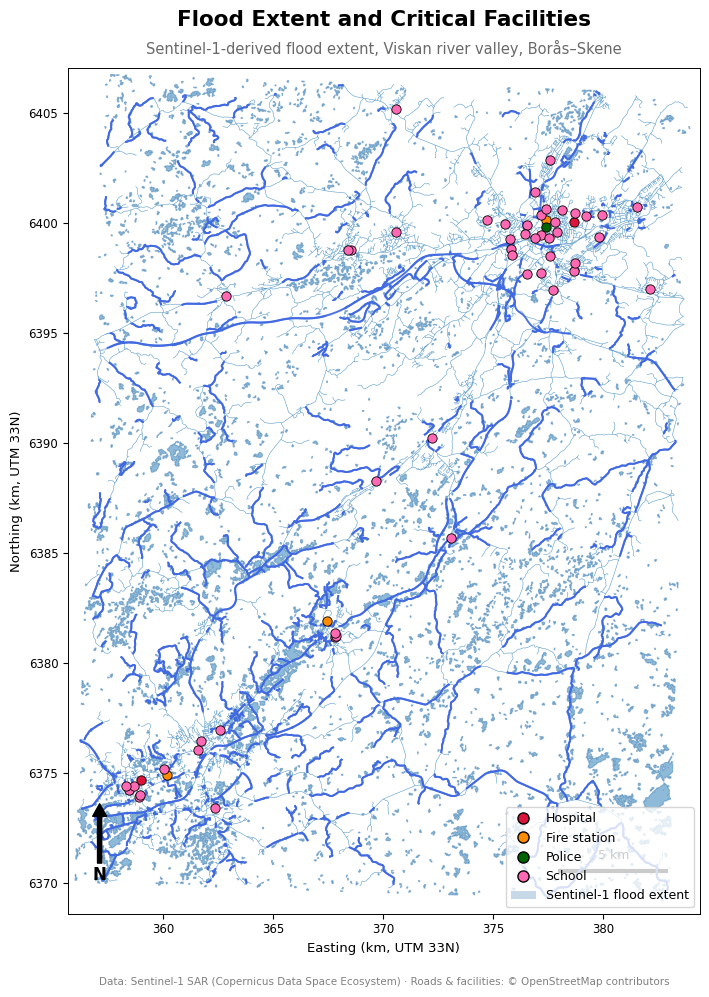

In [ ]:
import os
fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor("white")

edges_plot.plot(ax=ax, linewidth=0.35, alpha=0.45, zorder=1)
flood_metric.plot(ax=ax, alpha=0.50, edgecolor="steelblue", linewidth=0.7, zorder=2)

flooded_roads = edges_plot[edges_plot["flooded"]]
if not flooded_roads.empty:
    flooded_roads.plot(ax=ax, linewidth=1.4, alpha=0.9, color="royalblue", zorder=3)

any_facility_inside = False
for facility_type, group in critical_facilities.groupby("facility_type"):
    color = FACILITY_COLORS.get(facility_type, "black")
    outside, inside = group[~group["inside_flood"]], group[group["inside_flood"]]
    if not outside.empty:
        ax.scatter(outside.geometry.x, outside.geometry.y, s=45, marker="o", c=color, edgecolors="black", linewidths=0.6, zorder=5)
    if not inside.empty:
        ax.scatter(inside.geometry.x, inside.geometry.y, s=180, marker="*", c=color, edgecolors="black", linewidths=0.9, zorder=6)
        any_facility_inside = True

minx, miny, maxx, maxy = edges_plot.total_bounds
pad_x, pad_y = (maxx - minx) * 0.02, (maxy - miny) * 0.02
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_aspect("equal")

fig.suptitle("Flood Extent and Critical Facilities", fontsize=15.5, fontweight="bold", y=0.98)
ax.set_title("Sentinel-1-derived flood extent, Viskan river valley, Borås–Skene", fontsize=10.5, color="dimgray", pad=10)

# Axes in km instead of raw UTM metres -- more readable, standard for this map scale.
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y/1000:.0f}"))
ax.set_xlabel("Easting (km, UTM 33N)", fontsize=9.5)
ax.set_ylabel("Northing (km, UTM 33N)", fontsize=9.5)
ax.tick_params(labelsize=8.5)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.7)

legend_handles = [
    mlines.Line2D([], [], marker="o", linestyle="None", markerfacecolor=c, markeredgecolor="black", markersize=8, label=label)
    for label, c in FACILITY_COLORS.items()
]
if any_facility_inside:
    legend_handles.append(
        mlines.Line2D([], [], marker="*", linestyle="None", markerfacecolor="gray", markeredgecolor="black", markersize=13, label="Inside flood extent")
    )
legend_handles.append(mpatches.Patch(facecolor="steelblue", alpha=0.30, label="Sentinel-1 flood extent"))
ax.legend(handles=legend_handles, loc="lower right", fontsize=9, frameon=True)

# North arrow
ax.annotate("N", xy=(0.05, 0.13), xytext=(0.05, 0.04), xycoords="axes fraction",
            fontsize=12, fontweight="bold", ha="center",
            arrowprops=dict(facecolor="black", width=3, headwidth=10, headlength=9))

# Scale bar (5 km)
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
bar_length = 5000  # metres
bar_x0 = x1 - (x1 - x0) * 0.05 - bar_length
bar_y0 = y0 + (y1 - y0) * 0.05
ax.plot([bar_x0, bar_x0 + bar_length], [bar_y0, bar_y0], color="black", linewidth=3, solid_capstyle="butt")
ax.text(bar_x0 + bar_length / 2, bar_y0 + (y1 - y0) * 0.015, "5 km", ha="center", fontsize=9)

# Data source attribution -- standard for any figure meant to be reused/cited.
fig.text(0.5, 0.005, "Data: Sentinel-1 SAR (Copernicus Data Space Ecosystem) · Roads & facilities: © OpenStreetMap contributors",
          ha="center", fontsize=7.5, color="gray")

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

## 6. Flood-affected road network

A road segment is treated as **completely unavailable** the moment its geometry intersects the Sentinel-1 flood extent — a binary, all-or-nothing rule. We remove those segments from a copy of the normal road graph and use the result as the flood scenario.

**Why not use water depth instead?**

A more realistic model would treat a road as passable up to some depth (threshold) and impassable beyond it — a shallow puddle across a road doesn't close it the way half a meter of moving water does. We don't do this here for a concrete data reason: **SAR backscatter tells us where the surface is flooded, not how deep the water is.**

In [ ]:
G_flood = road_graph.copy()
affected_edges = edges_plot[edges_plot["flooded"]]

removed = 0
for row in affected_edges.itertuples():
    u, v, k = row.u, row.v, row.key
    for a, b in [(u, v), (v, u)]:
        if G_flood.has_edge(a, b, k):
            G_flood.remove_edge(a, b, k)
            removed += 1

print(f"Normal graph: {len(road_graph.edges):,} directed edges")
print(f"Flood graph:  {len(G_flood.edges):,} directed edges")
print(f"Removed:      {removed:,} directed edges")

Normal graph: 15,129 directed edges
Flood graph:  13,192 directed edges
Removed:      1,937 directed edges


## 7. Accessibility impact for all critical facilities

For each facility category, we calculate how much of the road network is reachable within 10 minutes in the normal and flood scenarios. The metric is total length of unique reachable road segments — a consistent screening metric across facility categories.

**Accessibility reduction (%)** is simply: how much of that reachable-road total disappears under flood conditions, relative to normal — `(normal km − flood km) / normal km × 100`. A value of **0%** means the flood didn't shrink the 10-minute reach at all for that category (even if some roads flooded, alternate routes fully compensated). A value near **100%** would mean almost nothing is reachable within 10 minutes anymore.

**Activity (optional)bold text:** the table ranks facility categories by how much *reachable road network* shrinks under flood conditions — not by how many facilities sit inside the flood extent (that's the "Inside flood extent" column, a different thing). A facility can be completely outside the flood zone and still become much harder to reach if the roads leading to it are cut. **Which of these two effects looks bigger for the top-ranked category?**


In [ ]:
ANALYSIS_TIME_MIN = 10

def snap_facilities(G, facilities):
    if facilities.empty:
        return []
    pts = facilities.to_crs(G.graph["crs"])
    nodes = ox.distance.nearest_nodes(G, X=pts.geometry.x.to_numpy(), Y=pts.geometry.y.to_numpy())
    return [n for n in np.atleast_1d(nodes).tolist() if n in G]

def reachable_edge_ids(G, facility_nodes, minutes):
    edge_ids = set()
    for node in facility_nodes:
        if node not in G:
            continue
        ego = nx.ego_graph(G, node, radius=minutes * 60, distance="travel_time")
        edge_ids.update(ego.edges(keys=True))
    return edge_ids

def reachable_edges_gdf(G, facilities, minutes=10):
    """Reachable road edges (as a GeoDataFrame, metric CRS) within `minutes` of any of `facilities`."""
    nodes = snap_facilities(G, facilities)
    ids = reachable_edge_ids(G, nodes, minutes)
    if not ids:
        return None
    graph_edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
    valid = [idx for idx in graph_edges.index if idx in ids]
    return graph_edges.loc[valid].to_crs(METRIC_CRS) if valid else None

def reachable_road_length_km(G, facilities, minutes=10):
    edges = reachable_edges_gdf(G, facilities, minutes)
    return edges.geometry.length.sum() / 1000 if edges is not None else 0.0

accessibility_rows = []
for facility_type in FACILITY_TAGS:
    facilities = critical_facilities[critical_facilities["facility_type"] == facility_type].copy()
    normal_km = reachable_road_length_km(road_graph, facilities, ANALYSIS_TIME_MIN)
    flood_km = reachable_road_length_km(G_flood, facilities, ANALYSIS_TIME_MIN)
    reduction = 100 * (normal_km - flood_km) / normal_km if normal_km > 0 else np.nan
    accessibility_rows.append({
        "Facility": facility_type,
        "N facilities": len(facilities),
        "Inside flood extent": int(facilities["inside_flood"].sum()),
        "Normal reachable roads (km)": normal_km,
        "Flood reachable roads (km)": flood_km,
        "Accessibility reduction (%)": max(0, reduction) if np.isfinite(reduction) else np.nan,
    })

accessibility_df = pd.DataFrame(accessibility_rows).sort_values(
    "Accessibility reduction (%)", ascending=False, na_position="last"
).reset_index(drop=True)

display(accessibility_df.style.format({
    "Normal reachable roads (km)": "{:.1f}",
    "Flood reachable roads (km)": "{:.1f}",
    "Accessibility reduction (%)": "{:.1f}%",
}))

most_affected = accessibility_df.dropna(subset=["Accessibility reduction (%)"]).iloc[0]["Facility"]
print(f"\nMost affected category: {most_affected}")

,Facility,N facilities,Inside flood extent,Normal reachable roads (km),Flood reachable roads (km),Accessibility reduction (%)
0,Fire station,3,0,2144.0,632.8,70.5%
1,Hospital,2,0,1516.2,570.9,62.3%
2,Police,1,0,1269.6,572.9,54.9%
3,School,50,0,3077.5,1422.3,53.8%



Most affected category: Fire station


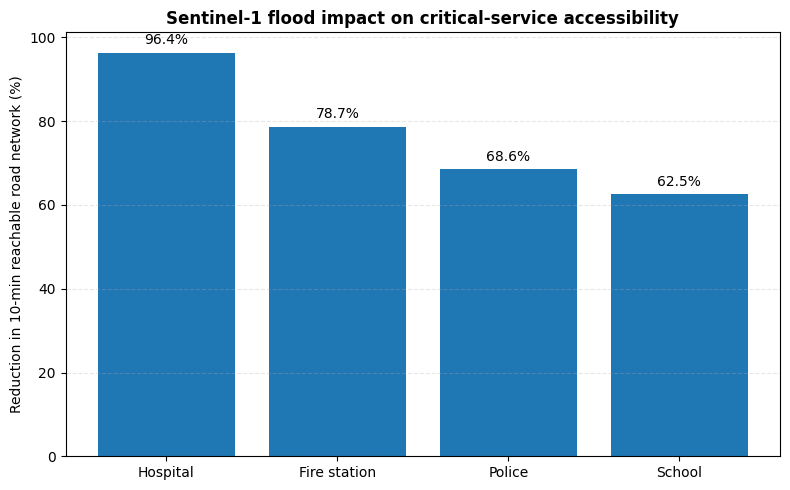

In [ ]:
plot_df = accessibility_df.dropna(subset=["Accessibility reduction (%)"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_df["Facility"], plot_df["Accessibility reduction (%)"])
ax.set_ylabel("Reduction in 10-min reachable road network (%)")
ax.set_title("Sentinel-1 flood impact on critical-service accessibility", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.3)

for i, value in enumerate(plot_df["Accessibility reduction (%)"]):
    ax.text(i, value + max(plot_df["Accessibility reduction (%)"].max() * 0.02, 0.05), f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## 8. Isochrones for the most affected critical facility

The facility category with the largest 10-minute accessibility reduction is selected automatically. We compare **5-, 10- and 15-minute** driving isochrones before and during the flood scenario for the most affected facility type **(hospitals)**.

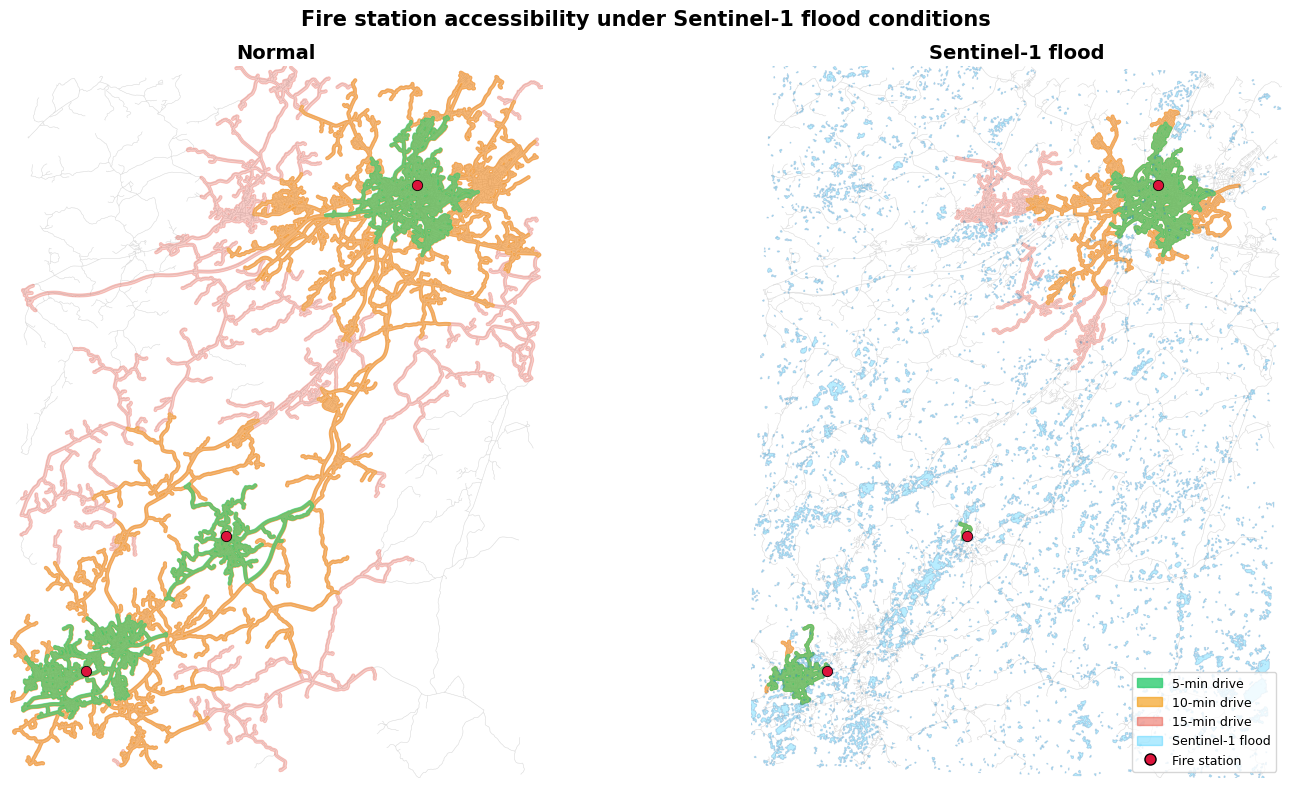

In [ ]:
ISO_TIMES = [5, 10, 15]
ISO_COLORS = {5: "#2ECC71", 10: "#F39C12", 15: "#E74C3C"}
ISO_ALPHA = {5: 0.60, 10: 0.45, 15: 0.28}

def build_isochrones(G, facilities, times=ISO_TIMES, buffer_m=80):
    records = []
    for t in times:
        edges = reachable_edges_gdf(G, facilities, t)
        if edges is None:
            continue
        area = unary_union(edges.geometry.buffer(buffer_m).tolist())
        records.append({"t_min": t, "geometry": area})
    return gpd.GeoDataFrame(records, geometry="geometry", crs=METRIC_CRS) if records else None

selected_facilities = critical_facilities[critical_facilities["facility_type"] == most_affected].copy()
iso_normal = build_isochrones(road_graph, selected_facilities)
iso_flood = build_isochrones(G_flood, selected_facilities)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, iso, title in zip(axes, [iso_normal, iso_flood], ["Normal", "Sentinel-1 flood"]):
    edges_plot.plot(ax=ax, color="lightgray", linewidth=0.35, alpha=0.55, zorder=1)
    if iso is not None:
        for t in reversed(ISO_TIMES):
            part = iso[iso["t_min"] == t]
            if not part.empty:
                part.plot(ax=ax, color=ISO_COLORS[t], alpha=ISO_ALPHA[t], edgecolor=ISO_COLORS[t], linewidth=0.7, zorder=2)
    if title == "Sentinel-1 flood":
        flood_metric.plot(ax=ax, color="deepskyblue", alpha=0.28, edgecolor="steelblue", linewidth=0.6, zorder=3)
    selected_facilities.plot(ax=ax, color="crimson", marker="o", markersize=55, edgecolor="black", linewidth=0.6, zorder=4)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight="bold")

handles = [mpatches.Patch(color=ISO_COLORS[t], alpha=ISO_ALPHA[t] + 0.2, label=f"{t}-min drive") for t in ISO_TIMES]
handles += [
    mpatches.Patch(color="deepskyblue", alpha=0.3, label="Sentinel-1 flood"),
    mlines.Line2D([], [], color="crimson", marker="o", linestyle="None", markeredgecolor="black", markersize=8, label=most_affected),
]
axes[1].legend(handles=handles, loc="lower right", fontsize=9)

reduction = accessibility_df.loc[accessibility_df["Facility"] == most_affected, "Accessibility reduction (%)"].iloc[0]
fig.suptitle(f"{most_affected} accessibility under Sentinel-1 flood conditions",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Exposure analyses: population and land cover

These two sections use raster files from **a pre-built GitHub repository** rather than a live download, so they'll work offline and stay reproducible. They're written to fail gracefully with a clear message if the file isn't there yet.

**Important:** both files were prepared for *this specific* `AOI_BBOX` — the population grid was clipped to it, and the land-cover raster was clipped and reprojected to match. If you follow Section 1's suggestion to change `AOI_BBOX` to a different EMSR427 area, these two files will no longer cover the right region.


### 9.1 Population exposure

**Expected file:** `data/population.tif` — a population-count (or density) raster covering the AOI, in any CRS (it's reprojected automatically). This notebook was built and tested against Statistics Sweden's (SCB) official 1&nbsp;km population grid.

We compute:
1. **Direct flood exposure** — population inside the Sentinel-1 flood extent.
2. **Accessibility exposure** — population inside the area reachable within 10 minutes of a **hospital** under normal conditions but *not* under flood conditions.
3. A **map** of population against the flood extent and all critical facilities.
4. The same accessibility-exposure metric **broken down by facility category and by time threshold** (5/10/15 min), so you can see how sensitive the result is to how "reachable" is defined.
5. A short **summary** with percentages, and a comparison of population density inside the flood extent vs. the AOI average.

**Activity (optional)**: before running the cells below, guess — **do you expect the flooded area to be more or less densely populated than the AOI average?**

Rivers often cut through both farmland and town centers, so it isn't obvious either way. Check your guess against Section's summary table once it runs.


Population in AOI:                              119,079
Population inside Sentinel-1 flood extent:      1,111
Population losing 10-min hospital access:       22,354


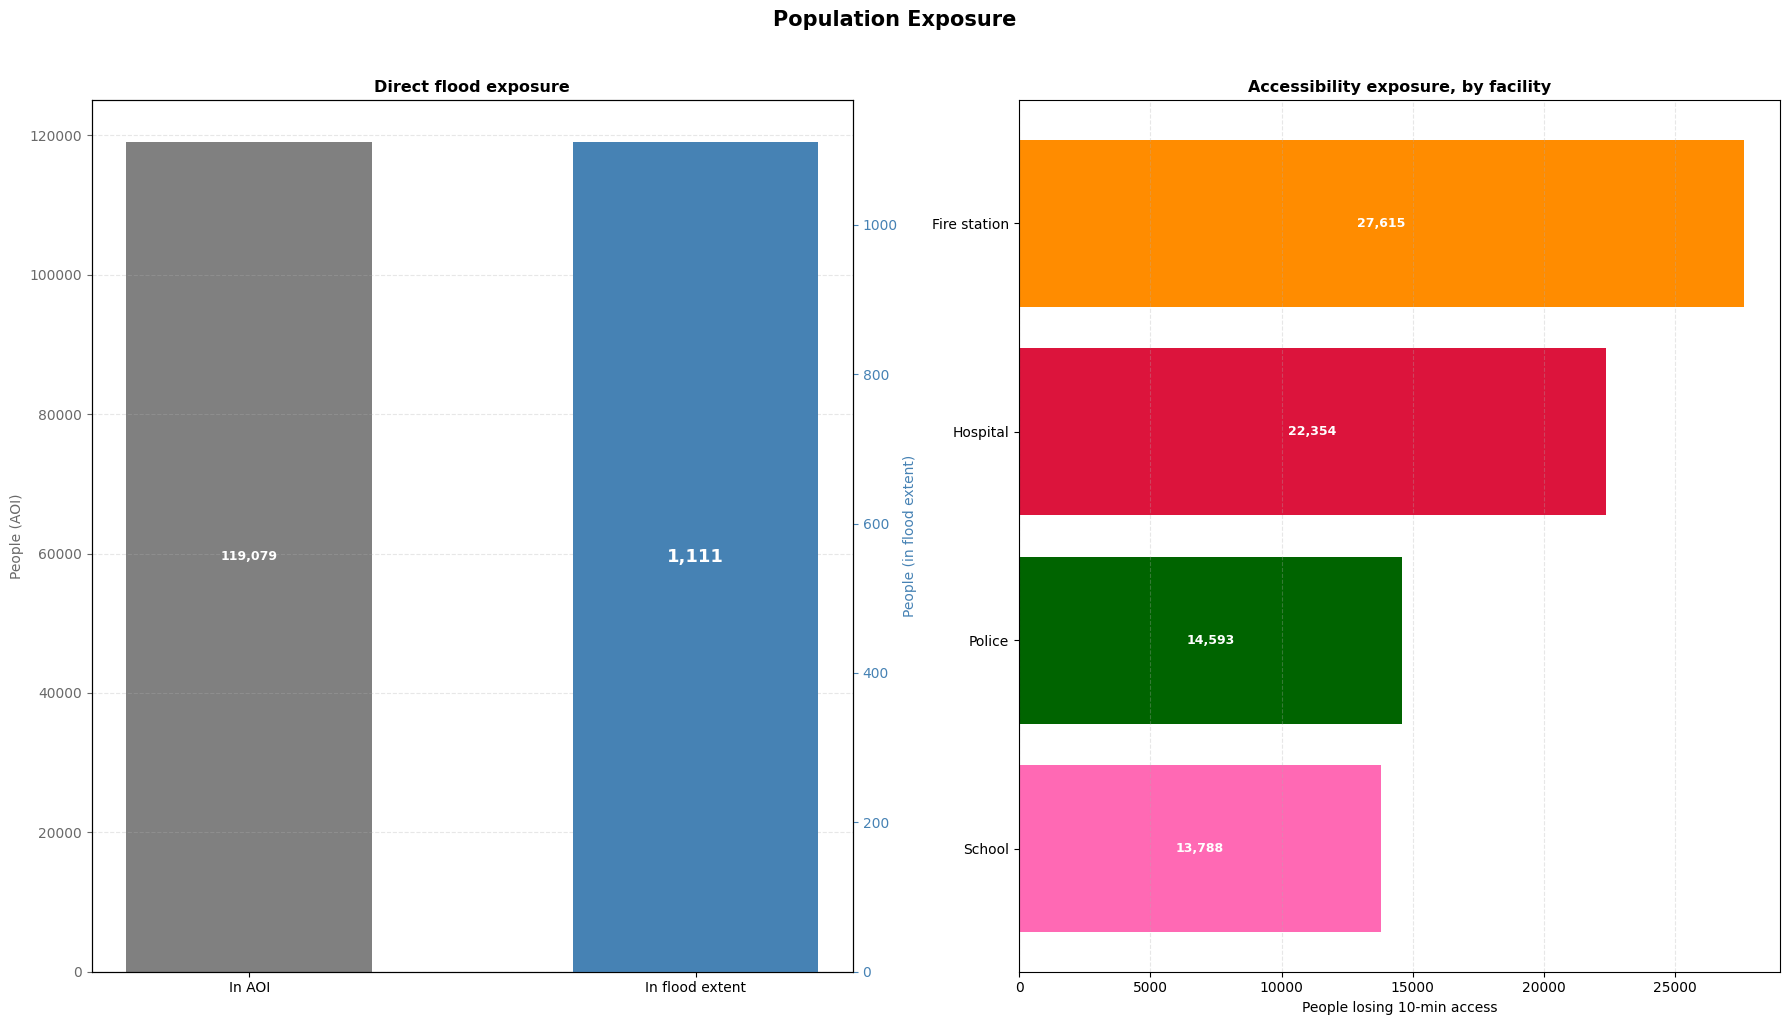

In [ ]:
POPULATION_RASTER_PATH = "data/population.tif"
POPULATION_RASTER_URL = "https://raw.githubusercontent.com/amaletaa/SESAC-Beginner_EO_Analysi_Series/main/population.tif"

os.makedirs("data", exist_ok=True)
if not os.path.exists(POPULATION_RASTER_PATH):
    try:
        print("Downloading population raster from GitHub...")
        urllib.request.urlretrieve(POPULATION_RASTER_URL, POPULATION_RASTER_PATH)
        print("Done.")
    except Exception as e:
        print(f"Download failed ({e}) -- add data/population.tif to your repo, or place it manually.")

def population_in_geometry(pop_da, geometry, crs=METRIC_CRS):
    """Sum of population raster cells intersecting `geometry` (a shapely geometry in `crs`)."""
    try:
        clipped = pop_da.rio.clip([geometry], crs=crs, drop=True)
        return float(np.nan_to_num(clipped.values).sum())
    except Exception:
        return 0.0  # geometry doesn't overlap the raster at all

def population_losing_access(pop_da, G_normal, G_flood_graph, facilities, minutes=ANALYSIS_TIME_MIN, buffer_m=80):
    """Population inside the area reachable within `minutes` under normal conditions but not under flood conditions."""
    normal_edges = reachable_edges_gdf(G_normal, facilities, minutes)
    if normal_edges is None:
        return 0.0
    flood_edges = reachable_edges_gdf(G_flood_graph, facilities, minutes)
    normal_area = unary_union(normal_edges.geometry.buffer(buffer_m).tolist())
    flood_area = unary_union(flood_edges.geometry.buffer(buffer_m).tolist()) if flood_edges is not None else None
    lost_access_area = normal_area.difference(flood_area) if flood_area is not None else normal_area
    return population_in_geometry(pop_da, lost_access_area)

if not os.path.exists(POPULATION_RASTER_PATH):
    print(f"No population raster found at '{POPULATION_RASTER_PATH}'.")
    print("Add a population GeoTIFF there (see Section 9.1 above) and re-run this cell.")
else:
    pop_da = rioxarray.open_rasterio(POPULATION_RASTER_PATH, masked=True).squeeze()
    if pop_da.rio.crs.to_string() != METRIC_CRS:
        pop_da = pop_da.rio.reproject(METRIC_CRS)

    aoi_metric_geom = gpd.GeoSeries([AOI_GEOM], crs="EPSG:4326").to_crs(METRIC_CRS).iloc[0]
    pop_total_aoi = population_in_geometry(pop_da, aoi_metric_geom)
    pop_in_flood = population_in_geometry(pop_da, flood_union)

    # Population losing 10-min access, per facility category -- reused by the more
    # detailed 5/10/15-min breakdown further below, computed once more here for the
    # quick overview panel.
    pop_access_by_facility = {
        facility_type: population_losing_access(
            pop_da, road_graph, G_flood,
            critical_facilities[critical_facilities["facility_type"] == facility_type],
        )
        for facility_type in FACILITY_TAGS
    }
    pop_losing_access = pop_access_by_facility["Hospital"]

    print(f"Population in AOI:                              {pop_total_aoi:,.0f}")
    print(f"Population inside Sentinel-1 flood extent:      {pop_in_flood:,.0f}")
    print(f"Population losing 10-min hospital access:       {pop_losing_access:,.0f}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.patch.set_facecolor("white")

    # --- Left: direct flood exposure, dual axis (population in flood extent is
    # usually much smaller than total AOI population, so a shared axis would make
    # the second bar nearly invisible) ---
    ax = axes[0]
    bar1 = ax.bar([0], [pop_total_aoi], width=0.55, color="gray")
    ax.set_ylabel("People (AOI)", color="dimgray")
    ax.tick_params(axis="y", colors="dimgray")
    ax.bar_label(bar1, fmt="{:,.0f}", label_type="center", color="white", fontweight="bold", fontsize=9)

    ax_twin = ax.twinx()
    bar2 = ax_twin.bar([1], [pop_in_flood], width=0.55, color="steelblue")
    ax_twin.set_ylabel("People (in flood extent)", color="steelblue")
    ax_twin.tick_params(axis="y", colors="steelblue")
    ax_twin.bar_label(bar2, fmt="{:,.0f}", label_type="center", color="white", fontweight="bold", fontsize=13)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["In AOI", "In flood extent"])
    ax.set_title("Direct flood exposure", fontsize=11.5, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # --- Right: accessibility exposure, by facility category ---
    ax2 = axes[1]
    facility_order = sorted(pop_access_by_facility, key=pop_access_by_facility.get, reverse=True)
    values = [pop_access_by_facility[f] for f in facility_order]
    colors = [FACILITY_COLORS.get(f, "gray") for f in facility_order]
    bars2 = ax2.barh(facility_order, values, color=colors)
    ax2.bar_label(bars2, fmt="{:,.0f}", label_type="center", color="white", fontweight="bold", fontsize=15)
    ax2.invert_yaxis()
    ax2.set_xlabel("People losing 10-min access")
    ax2.set_title("Accessibility exposure, by facility", fontsize=11.5, fontweight="bold")
    ax2.grid(axis="x", linestyle="--", alpha=0.3)

    fig.suptitle("Population Exposure", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

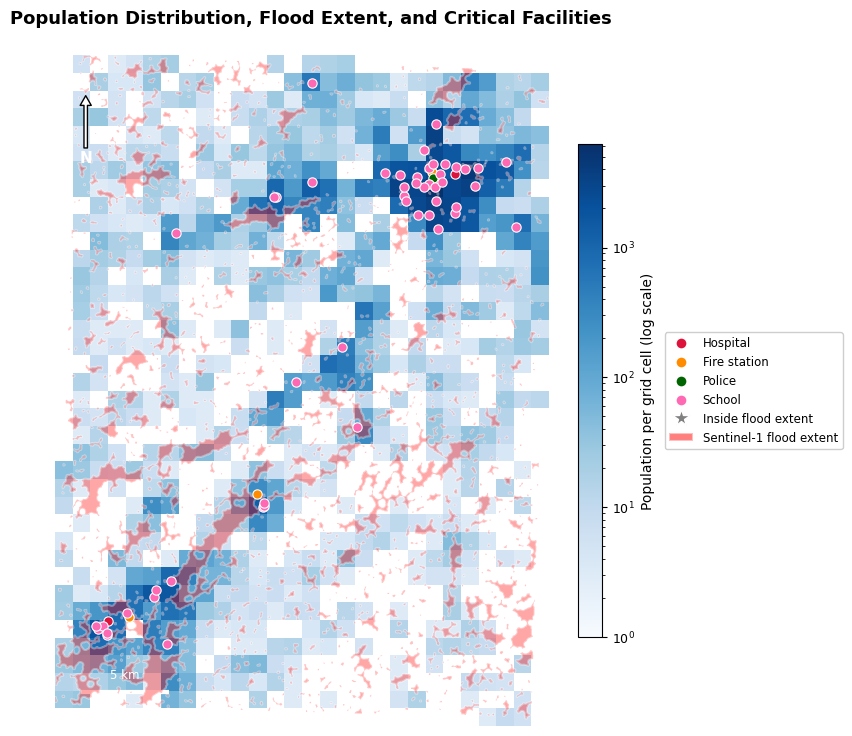

In [ ]:
if not os.path.exists(POPULATION_RASTER_PATH):
    print("Skipping population map -- no population raster found (see Section 9.1).")
else:
    from matplotlib.colors import LogNorm

    pop_masked = pop_da.where(pop_da > 0)
    vmax = float(pop_masked.max())

    # The raw flood_union is thousands of small SAR-speckle polygons -- fine for the
    # analysis, but renders as visual noise. For THIS MAP ONLY, apply a morphological
    # "closing" (dilate then erode) to merge nearby fragments into clean blobs.
    flood_smooth_geom = flood_union.buffer(150).buffer(-150)
    flood_outline = gpd.GeoDataFrame(geometry=[flood_smooth_geom], crs=METRIC_CRS)

    fig, ax = plt.subplots(figsize=(8, 7.5))
    fig.patch.set_facecolor("white")

    im = pop_masked.plot(
        ax=ax, cmap="Blues", norm=LogNorm(vmin=1, vmax=vmax), add_colorbar=False
    )
    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label("Population per grid cell (log scale)", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    flood_outline.plot(ax=ax, facecolor="red", alpha=0.35, edgecolor="white", linewidth=1.5, zorder=3)

    for facility_type, group in critical_facilities.groupby("facility_type"):
        color = FACILITY_COLORS.get(facility_type, "black")
        outside, inside = group[~group["inside_flood"]], group[group["inside_flood"]]
        if not outside.empty:
            ax.scatter(outside.geometry.x, outside.geometry.y, s=45, marker="o",
                       c=color, edgecolors="white", linewidths=0.8, zorder=5)
        if not inside.empty:
            ax.scatter(inside.geometry.x, inside.geometry.y, s=170, marker="*",
                       c=color, edgecolors="white", linewidths=0.9, zorder=6)

    ax.set_title("Population Distribution, Flood Extent, and Critical Facilities", fontsize=13, fontweight="bold", pad=12)
    ax.set_axis_off()

    legend_handles = [
        mlines.Line2D([], [], marker="o", linestyle="None", markerfacecolor=c,
                     markeredgecolor="white", markersize=8, label=label)
        for label, c in FACILITY_COLORS.items()
    ] + [
        mlines.Line2D([], [], marker="*", linestyle="None", markerfacecolor="gray",
                     markeredgecolor="white", markersize=13, label="Inside flood extent"),
        mpatches.Patch(facecolor="red", alpha=0.5, edgecolor="white", linewidth=1.5, label="Sentinel-1 flood extent"),
    ]
    # Outside the axes, to the right -- never overlaps the map or gets cut off.
    ax.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.18, 0.5),
              fontsize=8.5, frameon=True, facecolor="white", framealpha=0.95)

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.annotate("N", xy=(0.06, 0.94), xytext=(0.06, 0.84), xycoords="axes fraction",
                fontsize=11, fontweight="bold", ha="center", color="white",
                arrowprops=dict(facecolor="white", width=2.5, headwidth=8, headlength=7))

    bar_length = 5000
    bar_x0 = x0 + (x1 - x0) * 0.05
    bar_y0 = y0 + (y1 - y0) * 0.05
    ax.plot([bar_x0, bar_x0 + bar_length], [bar_y0, bar_y0], color="white", linewidth=3, solid_capstyle="butt")
    ax.text(bar_x0 + bar_length / 2, bar_y0 + (y1 - y0) * 0.02, "5 km", ha="center", fontsize=8.5, color="white")

    plt.tight_layout()
    plt.show()

,5-min,10-min,15-min
Facility,,,
Fire station,"9,335","27,615","28,975"
Hospital,"12,551","22,354","30,611"
Police,"7,981","14,593","15,835"
School,"13,226","13,788","13,709"


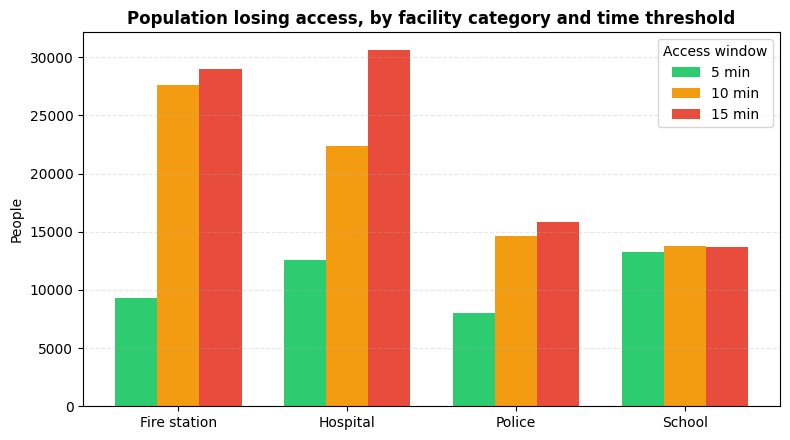

In [ ]:
if not os.path.exists(POPULATION_RASTER_PATH):
    print("Skipping per-facility population exposure -- no population raster found (see Section 9.1).")
else:
    pop_access_rows = [
        {
            "Facility": facility_type,
            "Minutes": minutes,
            "Population losing access": population_losing_access(
                pop_da, road_graph, G_flood,
                critical_facilities[critical_facilities["facility_type"] == facility_type],
                minutes=minutes,
            ),
        }
        for facility_type in FACILITY_TAGS
        for minutes in ISO_TIMES
    ]
    pop_access_df = pd.DataFrame(pop_access_rows)

    # Wide table: one row per facility, one column per time threshold -- easy to read at a glance.
    pop_access_wide = pop_access_df.pivot(index="Facility", columns="Minutes", values="Population losing access")
    pop_access_wide.columns = [f"{m}-min" for m in pop_access_wide.columns]
    pop_access_wide = pop_access_wide.loc[pop_access_wide["10-min"].sort_values(ascending=False).index]
    display(pop_access_wide.style.format("{:,.0f}"))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    facilities_order = pop_access_wide.index.tolist()
    x = np.arange(len(facilities_order))
    width = 0.25

    for i, minutes in enumerate(ISO_TIMES):
        values = [
            pop_access_df[(pop_access_df["Facility"] == f) & (pop_access_df["Minutes"] == minutes)]
            ["Population losing access"].iloc[0]
            for f in facilities_order
        ]
        ax.bar(x + (i - 1) * width, values, width, label=f"{minutes} min", color=ISO_COLORS[minutes])

    ax.set_xticks(x)
    ax.set_xticklabels(facilities_order)
    ax.set_ylabel("People")
    ax.set_title("Population losing access, by facility category and time threshold", fontweight="bold")
    ax.legend(title="Access window")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
if not os.path.exists(POPULATION_RASTER_PATH):
    print("Skipping population summary -- no population raster found (see Section 9.1).")
else:
    aoi_area_km2 = aoi_metric_geom.area / 1e6
    flood_area_km2 = flood_metric.geometry.area.sum() / 1e6

    pct_in_flood = 100 * pop_in_flood / pop_total_aoi if pop_total_aoi > 0 else np.nan
    pct_losing_hospital = 100 * pop_losing_access / pop_total_aoi if pop_total_aoi > 0 else np.nan
    density_aoi = pop_total_aoi / aoi_area_km2 if aoi_area_km2 > 0 else np.nan
    density_flood = pop_in_flood / flood_area_km2 if flood_area_km2 > 0 else np.nan

    summary_df = pd.DataFrame([
        {"Metric": "Population in AOI", "Value": f"{pop_total_aoi:,.0f}"},
        {"Metric": "Population in flood extent", "Value": f"{pop_in_flood:,.0f} ({pct_in_flood:.1f}% of AOI)"},
        {"Metric": "Population losing 10-min hospital access", "Value": f"{pop_losing_access:,.0f} ({pct_losing_hospital:.1f}% of AOI)"},
        {"Metric": "Average density, whole AOI", "Value": f"{density_aoi:,.0f} people/km²"},
        {"Metric": "Average density, flooded area", "Value": f"{density_flood:,.0f} people/km²"},
    ])
    display(summary_df)

    if density_flood > density_aoi:
        print(f"\nThe flooded area is ~{density_flood/density_aoi:.1f}x more densely populated than the AOI "
              "average -- the flood is disproportionately affecting built-up/populated land, not just open countryside.")
    else:
        print("\nThe flooded area is less densely populated than the AOI average -- "
              "consistent with flooding concentrated along the river valley rather than urban cores.")

,Metric,Value
0,Population in AOI,"119,079"
1,Population in flood extent,"1,111 (0.9% of AOI)"
2,Population losing 10-min hospital access,"22,354 (18.8% of AOI)"
3,"Average density, whole AOI",121 people/km²
4,"Average density, flooded area",23 people/km²



The flooded area is less densely populated than the AOI average -- consistent with flooding concentrated along the river valley rather than urban cores.


### 9.2 Land cover exposure

**Expected file:** `data/landcover.tif` — a classified land-cover raster covering the AOI, in any CRS. This notebook was built and tested against Sweden's **National Land Cover Database (NMD2018)**, published by Naturvårdsverket (the Swedish EPA) under a CC0 license.

`LANDCOVER_CLASSES` below maps NMD2018 class codes to readable names, taken from the official [NMD2018 product description](https://www.naturvardsverket.se/4ac32f/contentassets/1db9f81262af4729ac8da0e54fa0808c/nmd2018-product-description-v2-eng.pdf).

We compute:
1. **Flooded area by class** — raw composition of the flood extent.
2. **Does SAR sensitivity depend on land cover?** — the mean SAR backscatter drop per class, checked against the flood-detection threshold from Section 3. This is a direct quality check on the flood mask itself: classes whose typical drop falls short of the threshold (often forest, where canopy blocks the radar return) are places the SAR method likely *misses* real flooding, not just places that happen to be dry.
3. **Relative exposure** — of each class's *total* area in the AOI, what percentage actually flooded. This is more informative than #1 alone: a class can dominate the flood extent simply because it's the dominant land cover everywhere, not because it's disproportionately affected.

**Activity (optional):** before running the cells below, make two guesses:
- Which land-cover class do you expect the SAR method to be *worst* at detecting flooding in — forest, arable land, or open wetland?
- Which class do you expect to be *disproportionately* flooded relative to its total size in the AOI?

Check both guesses against the SAR-sensitivity chart and the relative-exposure table once they run.

**Quality-check reminder:** if a class you'd never expect near a river (e.g. a large share of "Building") shows up heavily flooded, that's worth flagging as a possible false positive in the SAR flood mask, not necessarily a real finding — check it against #2 above, and see if tightening Section 3's threshold values changes the picture.

Done.


,Class,Flooded area (km²),% of flood extent
0,Open wetland,11.226,23.0%
1,Arable land,10.698,21.9%
2,Inland water,7.160,14.7%
3,Vegetated other open land,5.169,10.6%
4,"Temporarily non-forest, not on wetland",5.131,10.5%
5,"Artificial surface, road/railway",1.619,3.3%
6,"Pine forest, on wetland",1.588,3.3%
7,"Spruce forest, not on wetland",1.411,2.9%
8,"Pine forest, not on wetland",1.065,2.2%
9,"Deciduous hardwood forest, not on wetland",0.923,1.9%


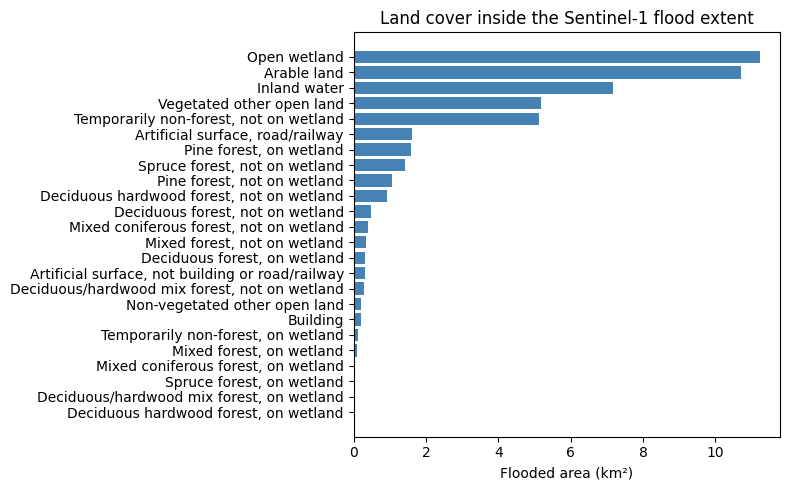

In [ ]:
LANDCOVER_RASTER_PATH = "data/landcover.tif"
LANDCOVER_RASTER_URL = "https://raw.githubusercontent.com/amaletaa/SESAC-Beginner_EO_Analysi_Series/main/landcover.tif"

os.makedirs("data", exist_ok=True)
if not os.path.exists(LANDCOVER_RASTER_PATH):
    try:
        print("Downloading land-cover raster from GitHub...")
        urllib.request.urlretrieve(LANDCOVER_RASTER_URL, LANDCOVER_RASTER_PATH)
        print("Done.")
    except Exception as e:
        print(f"Download failed ({e}) -- add data/landcover.tif to your repo, or place it manually.")

# NMD2018 class codes -- fill in from the unique codes the prep script printed,
# cross-checked against the NMD2018 product description PDF.
LANDCOVER_CLASSES = {
    2:   "Open wetland",
    3:   "Arable land",
    41:  "Non-vegetated other open land",
    42:  "Vegetated other open land",
    51:  "Building",
    52:  "Artificial surface, not building or road/railway",
    53:  "Artificial surface, road/railway",
    61:  "Inland water",
    111: "Pine forest, not on wetland",
    112: "Spruce forest, not on wetland",
    113: "Mixed coniferous forest, not on wetland",
    114: "Mixed forest, not on wetland",
    115: "Deciduous forest, not on wetland",
    116: "Deciduous hardwood forest, not on wetland",
    117: "Deciduous/hardwood mix forest, not on wetland",
    118: "Temporarily non-forest, not on wetland",
    121: "Pine forest, on wetland",
    122: "Spruce forest, on wetland",
    123: "Mixed coniferous forest, on wetland",
    124: "Mixed forest, on wetland",
    125: "Deciduous forest, on wetland",
    126: "Deciduous hardwood forest, on wetland",
    127: "Deciduous/hardwood mix forest, on wetland",
    128: "Temporarily non-forest, on wetland"}

if not os.path.exists(LANDCOVER_RASTER_PATH):
    print(f"No land-cover raster found at '{LANDCOVER_RASTER_PATH}'.")
    print("Add a classified land-cover GeoTIFF there (see Section 9.2 above) and re-run this cell.")
else:
    lc_da = rioxarray.open_rasterio(LANDCOVER_RASTER_PATH, masked=True).squeeze()
    if lc_da.rio.crs.to_string() != METRIC_CRS:
        lc_da = lc_da.rio.reproject(METRIC_CRS)

    lc_flood = lc_da.rio.clip([flood_union], crs=METRIC_CRS, drop=True)
    values, counts = np.unique(lc_flood.values[~np.isnan(lc_flood.values)], return_counts=True)

    lc_pixel_area = abs(lc_da.rio.resolution()[0] * lc_da.rio.resolution()[1])
    lc_rows = [{
        "Class": LANDCOVER_CLASSES.get(int(v), f"Class {int(v)}"),
        "Flooded area (km²)": counts[i] * lc_pixel_area / 1e6,
    } for i, v in enumerate(values)]

    lc_df = pd.DataFrame(lc_rows).sort_values("Flooded area (km²)", ascending=False).reset_index(drop=True)
    lc_df["% of flood extent"] = 100 * lc_df["Flooded area (km²)"] / lc_df["Flooded area (km²)"].sum()
    display(lc_df.style.format({"Flooded area (km²)": "{:.3f}", "% of flood extent": "{:.1f}%"}))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(lc_df["Class"], lc_df["Flooded area (km²)"], color="steelblue")
    ax.set_xlabel("Flooded area (km²)")
    ax.set_title("Land cover inside the Sentinel-1 flood extent")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


**Activity (optional):** before running the cells below, make two guesses:

- Which land-cover class do you expect the SAR method to be *worst* at detecting flooding in — forest, arable land, or open wetland?
- Which class do you expect to be *disproportionately* flooded relative to its total size in the AOI — not just present in the flood extent, but flooded well beyond its "fair share"?

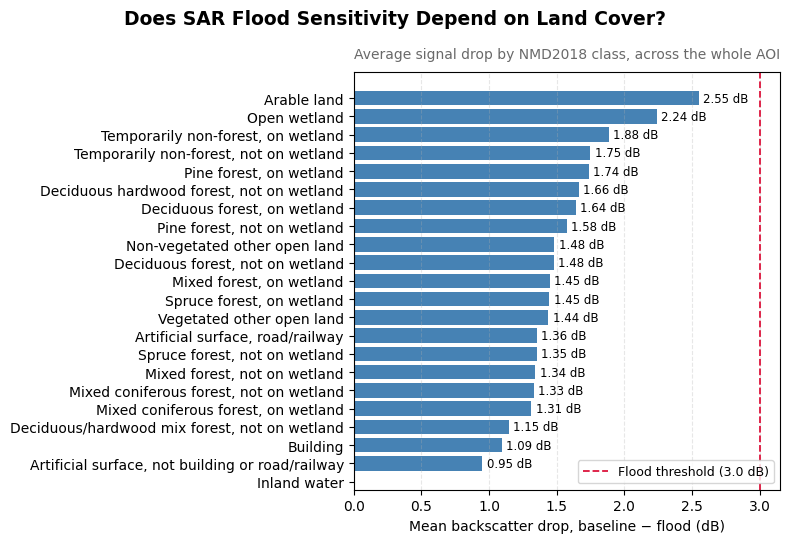

Classes whose bar falls short of the red line lose sensitivity to real flooding under
this threshold -- often forest (canopy blocks the radar return) or already-wet classes
like wetland (little further drop possible). This doesn't mean the SAR result is wrong
everywhere -- it means interpret flood extent over those classes with extra caution.


In [ ]:
if not os.path.exists(LANDCOVER_RASTER_PATH):
    print("Skipping SAR-vs-land-cover cross-check -- no land-cover raster found (see Section 9.2).")
else:
    # Align the land-cover raster onto the same grid as the SAR 'drop' array
    # (baseline - flood, in dB) so we can compare them pixel-for-pixel.
    lc_on_sar_grid = lc_da.rio.reproject_match(drop)

    drop_values = drop.values.ravel()
    lc_values = lc_on_sar_grid.values.ravel()
    valid = ~np.isnan(drop_values) & ~np.isnan(lc_values)

    df_compare = pd.DataFrame({
        "drop_db": drop_values[valid],
        "class_code": lc_values[valid].astype(int),
    })
    df_compare["Class"] = df_compare["class_code"].map(lambda c: LANDCOVER_CLASSES.get(c, f"Class {c}"))

    # Only classes with enough pixels to be statistically meaningful.
    class_counts = df_compare["Class"].value_counts()
    common_classes = class_counts[class_counts > 500].index

    stats = (
        df_compare[df_compare["Class"].isin(common_classes)]
        .groupby("Class")["drop_db"]
        .mean()
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(8, 5.5))
    fig.patch.set_facecolor("white")
    bars = ax.barh(stats.index, stats.values, color="steelblue")
    ax.bar_label(bars, fmt="%.2f dB", padding=3, fontsize=8.5)
    ax.axvline(DB_DROP_THRESHOLD, color="crimson", linestyle="--", linewidth=1.3, label=f"Flood threshold ({DB_DROP_THRESHOLD} dB)")
    ax.invert_yaxis()
    ax.set_xlabel("Mean backscatter drop, baseline − flood (dB)")
    fig.suptitle("Does SAR Flood Sensitivity Depend on Land Cover?", fontsize=13.5, fontweight="bold", y=0.98)
    ax.set_title("Average signal drop by NMD2018 class, across the whole AOI", fontsize=10, color="dimgray", pad=10)
    ax.legend(fontsize=9, loc = "lower right")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Classes whose bar falls short of the red line lose sensitivity to real flooding under")
    print("this threshold -- often forest (canopy blocks the radar return) or already-wet classes")
    print("like wetland (little further drop possible). This doesn't mean the SAR result is wrong")
    print("everywhere -- it means interpret flood extent over those classes with extra caution.")

,Class,Flooded area (km²),AOI area (km²),% of that class flooded
0,Arable land,10.698,32.421,33.0%
1,Open wetland,11.226,48.952,22.9%
2,Inland water,7.160,50.682,14.1%
3,Non-vegetated other open land,0.216,1.605,13.4%
4,"Temporarily non-forest, on wetland",0.124,1.999,6.2%
5,Vegetated other open land,5.169,90.050,5.7%
6,"Temporarily non-forest, not on wetland",5.131,113.599,4.5%
7,"Artificial surface, road/railway",1.619,37.546,4.3%
8,"Artificial surface, not building or road/railway",0.319,7.535,4.2%
9,"Deciduous hardwood forest, not on wetland",0.923,24.270,3.8%


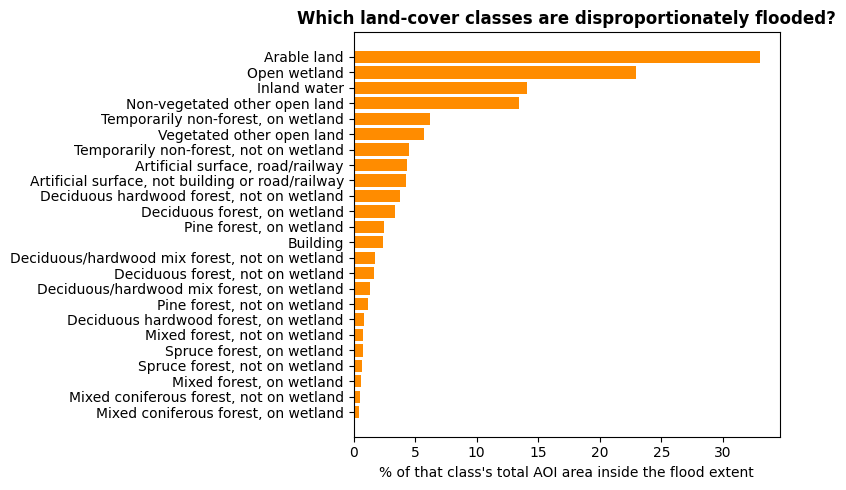

In [ ]:
if not os.path.exists(LANDCOVER_RASTER_PATH):
    print("Skipping land-cover representation check -- no land-cover raster found (see Section 9.2).")
else:
    aoi_metric_geom_lc = gpd.GeoSeries([AOI_GEOM], crs="EPSG:4326").to_crs(METRIC_CRS).iloc[0]
    lc_aoi_full = lc_da.rio.clip([aoi_metric_geom_lc], crs=METRIC_CRS, drop=True)
    values_aoi, counts_aoi = np.unique(lc_aoi_full.values[~np.isnan(lc_aoi_full.values)], return_counts=True)

    aoi_area_by_class = {
        LANDCOVER_CLASSES.get(int(v), f"Class {int(v)}"): counts_aoi[i] * lc_pixel_area / 1e6
        for i, v in enumerate(values_aoi)
    }

    compare_df = lc_df[["Class", "Flooded area (km²)"]].copy()
    compare_df["AOI area (km²)"] = compare_df["Class"].map(aoi_area_by_class).fillna(0)
    compare_df["% of that class flooded"] = 100 * compare_df["Flooded area (km²)"] / compare_df["AOI area (km²)"].replace(0, np.nan)
    compare_df = compare_df.sort_values("% of that class flooded", ascending=False).reset_index(drop=True)

    display(compare_df.style.format({
        "Flooded area (km²)": "{:.3f}", "AOI area (km²)": "{:.3f}", "% of that class flooded": "{:.1f}%"
    }))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(compare_df["Class"], compare_df["% of that class flooded"], color="darkorange")
    ax.set_xlabel("% of that class's total AOI area inside the flood extent")
    ax.set_title("Which land-cover classes are disproportionately flooded?", fontweight="bold")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()